# DCAF15–α-synuclein monomer simulation analysis

This notebook reproduces Figures S3B, S3C, 3F, 3G and 3H: single-chain
(monomer) CALVADOS simulations of the disordered protein α-synuclein (aSyn)
together with DCAF15, for wild-type DCAF15 and three charge-neutralized
DCAF15 surface variants (4, 8 and 12 positively charged residues mutated to
alanine).

**Expected data layout** (`../data/`, downloaded separately — see the
repository [README](../README.md)):

```
data/
├── residues_CALVADOS3.csv
└── uniprot_variants/
    ├── base/     # wild-type DCAF15
    ├── pos4/     # 4x Ala variant
    ├── pos8/     # 8x Ala variant
    └── pos12/    # 12x Ala variant
        └── <1..10>/data/          # one folder per replicate
            ├── asyn_dcaf15_com_traj.dcd
            ├── asyn_dcaf15_com_top.pdb
            ├── asyn_dcaf15_asyn_dcaf15_cmap.npy
            ├── asyn_dcaf15_dcaf15_rg.npy
            └── asyn_dcaf15_asyn_rg.npy
```

Figures are written to `../figures/`.


### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import mdtraj as md
from pathlib import Path
from scipy.constants import Avogadro


In [2]:
hexcolors = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB']
colornames = ['orange','blue','cyan','magenta','red','teal','grey']
pt_colors = dict(zip(colornames,hexcolors))

plt.rcParams["svg.fonttype"] = "none"


In [3]:
DCAF_col = '#8DAFDB'
DCAF_col_12xAla = '#F27C78'

KUred = "#901a1e"
KUgreen = "#4fd868"
KUpink = "#ffccc9"
KUdarkblue = "#143642"
KUblue = "#89ADC5"
KUorange = "#ff8135"
KUbeige = "#ede4d7"


In [4]:
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'


In [5]:
# Paths, relative to this notebook (notebooks/)
DATA_DIR = Path('../data')
VARIANTS_DIR = DATA_DIR / 'uniprot_variants'
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)


### Functions

In [6]:
def correct_RDF(r, rdf, L):
    # Ganguly and van der Vegt, DOI: 10.1021/ct301017q
    dr = r[1] - r[0]
    V = L**3
    Nouter = 1 - 4/3*np.pi*r**3 / V
    DeltaN = 1/V*4*np.pi*dr*np.cumsum((rdf - 1) * r**2)
    return rdf * Nouter / (Nouter - DeltaN)


def calc_B2(r, rdf, L, MW_1, MW_2):
    B2 = -2*np.pi*np.trapz((rdf - 1)*r*r, r)
    return B2 * Avogadro / 1e18 / (MW_1*MW_2)  # L mol / kg^2


In [7]:
def plotMap(fig, ax, df, label, vmin, vmax, cmap=plt.cm.Blues,
            xlabel='Single Chain', ylabel='Single Chain', ori='vertical', cbar=True):
    im = ax.imshow(df, extent=[1, df.shape[1], 1, df.shape[0]], cmap=cmap, origin='lower',
                    alpha=1, aspect='equal', vmin=vmin, vmax=vmax, interpolation='bicubic')
    if cbar:
        divider = make_axes_locatable(ax)
        if ori == 'vertical':
            cax = divider.new_horizontal(size="5%", pad=.1)
        else:
            cax = divider.new_vertical(size="5%", pad=.15)
        fig.add_axes(cax)
        cb = fig.colorbar(im, cax=cax, orientation=ori, label='{:s}'.format(label))
        cax.xaxis.set_label_position('top'); cax.xaxis.set_ticks_position('top')
    if xlabel:
        ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


In [8]:
def lighten(color, f=0.5):
    """Blend a colour toward white by fraction f (0 = same colour, 1 = white)."""
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * f, g + (1 - g) * f, b + (1 - b) * f)


In [9]:
def load_variant(variant_dir, n_reps=10, L=40, bin_width=1, MW_1=None, MW_2=None):
    """Load COM-COM distance, RDF/B2 and contact-map statistics for one DCAF15 variant."""
    variant_dir = Path(variant_dir)
    d1 = variant_dir / '1' / 'data'
    tc = md.load(str(d1 / 'asyn_dcaf15_com_traj.dcd'),
                 top=str(d1 / 'asyn_dcaf15_com_top.pdb'))
    dist = md.compute_distances(tc, atom_pairs=[[0, 1]], periodic=True)[:, 0]

    r_list, rdf_list, corr_rdf_list, b2_list = [], [], [], []
    dcaf_all, asyn_all = [], []
    for n in range(1, n_reps + 1):
        dp = variant_dir / str(n) / 'data'
        tcn = md.load(str(dp / 'asyn_dcaf15_com_traj.dcd'),
                      top=str(dp / 'asyn_dcaf15_com_top.pdb'))
        r, rdf = md.compute_rdf(tcn, pairs=[[0, 1]], r_range=(0, 25),
                                 bin_width=bin_width, periodic=True)
        r, rdf = r[r < L / 2], rdf[r < L / 2]
        corr = correct_RDF(r, rdf, L)
        r_list.append(r); rdf_list.append(rdf); corr_rdf_list.append(corr)
        b2_list.append(calc_B2(r, corr, L, MW_1, MW_2))

        cmap = np.load(str(dp / 'asyn_dcaf15_asyn_dcaf15_cmap.npy'))   # (140, 600)
        dcaf_all.append(np.sum(cmap, axis=0))                         # (600,)
        asyn_all.append(np.sum(cmap, axis=1))                         # (140,)

    return dict(
        dist         = dist,
        r_list       = r_list,
        rdf_avg      = np.mean(rdf_list, axis=0),
        rdf_std      = np.std(rdf_list, axis=0, ddof=1),
        corr_rdf_avg = np.mean(corr_rdf_list, axis=0),
        b2_avg       = np.mean(b2_list),
        b2_std       = np.std(b2_list, ddof=1),
        dcaf15_avg   = np.mean(dcaf_all, axis=0),
        dcaf15_std   = np.std(dcaf_all, axis=0, ddof=1),
        asyn_avg     = np.mean(asyn_all, axis=0),
        asyn_std     = np.std(asyn_all, axis=0, ddof=1),
    )


def load_average_cmap(variant_dir, n_reps=10):
    """Average the per-replicate aSyn-DCAF15 contact maps for one variant."""
    variant_dir = Path(variant_dir)
    cmaps = [np.load(str(variant_dir / str(n) / 'data' / 'asyn_dcaf15_asyn_dcaf15_cmap.npy'))
             for n in range(1, n_reps + 1)]
    return np.mean(cmaps, axis=0)


In [10]:
# sequences from Uniprot
dcaf15_fasta = "MAPSSKSERNSGAGSGGGGPGGAGGKRAAGRRREHVLKQLERVKISGQLSPRLFRKLPPRVCVSLKNIVDEDFLYAGHIFLGFSKCGRYVLSYTSSSGDDDFSFYIYHLYWWEFNVHSKLKLVRQVRLFQDEEIYSDLYLTVCEWPSDASKVIVFGFNTRSANGMLMNMMMMSDENHRDIYVSTVAVPPPGRCAACQDASRAHPGDPNAQCLRHGFMLHTKYQVVYPFPTFQPAFQLKKDQVVLLNTSYSLVACAVSVHSAGDRSFCQILYDHSTCPLAPASPPEPQSPELPPALPSFCPEAAPARSSGSPEPSPAIAKAKEFVADIFRRAKEAKGGVPEEARPALCPGPSGSRCRAHSEPLALCGETAPRDSPPASEAPASEPGYVNYTKLYYVLESGEGTEPEDELEDDKISLPFVVTDLRGRNLRPMRERTAVQGQYLTVEQLTLDFEYVINEVIRHDATWGHQFCSFSDYDIVILEVCPETNQVLINIGLLLLAFPSPTEEGQLRPKTYHTSLKVAWDLNTGIFETVSVGDLTEVKGQTSGSVWSSYRKSCVDMVMKWLVPESSGRYVNRMTNEALHKGCSLKVLADSERYTWIVL"
asyn_fasta = 'MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVVHGVATVAEKTKEQVTNVGGAVVTGVTAVAQKTVEGAGSIAAATGFVKKDQLGKNEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA'


In [11]:
# load residue information from CALVADOS 3 and compute molecular weights (+18 for the terminal water)
df_residues = pd.read_csv(DATA_DIR / 'residues_CALVADOS3.csv', index_col=0)
MW_1 = df_residues.loc[list(asyn_fasta)].MW.sum() + 18
MW_2 = df_residues.loc[list(dcaf15_fasta)].MW.sum() + 18


## Figures S3B, S3C, 3.F, 3.G

In [12]:
base = load_variant(VARIANTS_DIR / 'base', MW_1=MW_1, MW_2=MW_2)
pos12 = load_variant(VARIANTS_DIR / 'pos12', MW_1=MW_1, MW_2=MW_2)

for name, D in [('WT', base), ('12xAla', pos12)]:
    print(f"{name}: B2 = {D['b2_avg']:.3f} ± {D['b2_std']:.3f} L·mol/kg^2")


WT: B2 = 2.212 ± 0.278 L·mol/kg^2
12xAla: B2 = 2.356 ± 0.413 L·mol/kg^2


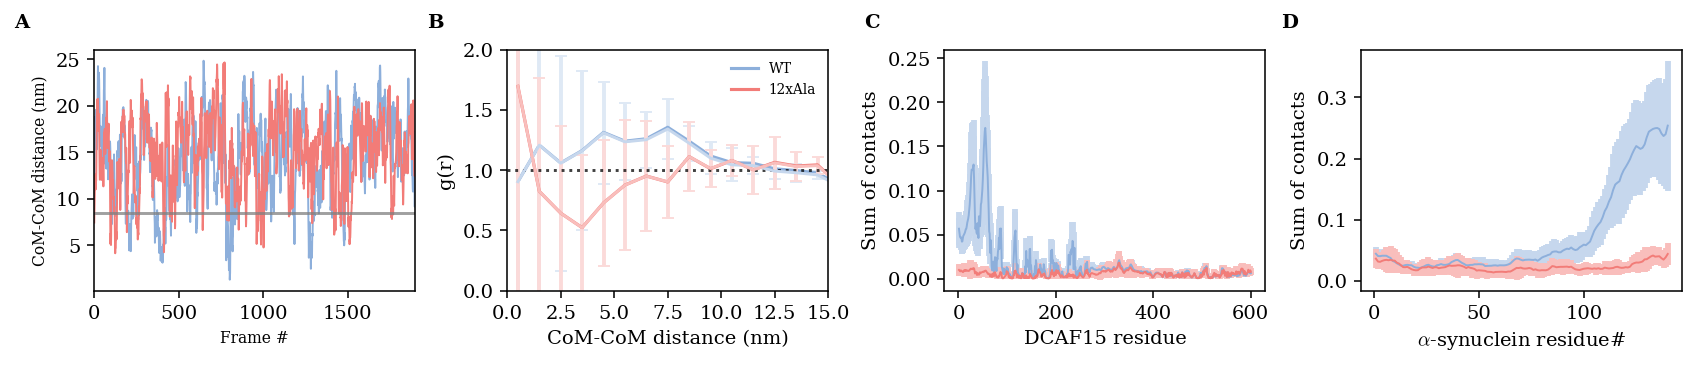

In [13]:
datasets = [
    ('WT',      DCAF_col,        base),
    ('12xAla',  DCAF_col_12xAla, pos12),
]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    1, 4,
    figsize=(12, 2.5),
    dpi=140,
    constrained_layout=True
)
plt.rcParams.update({'font.size': 8})

for name, col, D in datasets:
    col_light = lighten(col)

    # A: COM-COM timeseries (replicate 1, first 2000 frames)
    ax1.plot(D['dist'].flatten()[:2000], color=col, lw=1, label=name)

    # B: RDF -- raw g(r) (faint) + finite-size-corrected g(r) (bold, labelled)
    ax2.errorbar(D['r_list'][0], D['rdf_avg'], yerr=D['rdf_std'],
                 color=col_light, ecolor=lighten(col, 0.72),
                 capsize=3, elinewidth=2)
    ax2.plot(D['r_list'][0], D['corr_rdf_avg'], color=col, lw=1.6, label=name)

    # C: DCAF15 contact numbers
    ax3.errorbar(range(1, len(D['dcaf15_avg']) + 1), D['dcaf15_avg'], yerr=D['dcaf15_std'],
                 lw=1, elinewidth=3, color=col, ecolor=col_light)

    # D: aSyn contact numbers
    ax4.errorbar(range(1, len(D['asyn_avg']) + 1), D['asyn_avg'], yerr=D['asyn_std'],
                 lw=1, elinewidth=3, color=col, ecolor=col_light)

# reference lines
ax1.axhline(y=8.522, color="gray", ls="-", alpha=0.75)
ax2.hlines(xmin=0, xmax=20, y=1, color="black", ls="dotted", alpha=0.75)

ax1.set_xlabel("Frame #", fontsize=8)
ax1.set_ylabel("CoM-CoM distance (nm)", fontsize=8)
ax1.set_xlim(0, 1900)

ax2.set_xlim(0, 15)
ax2.set_ylim(0, 2)
ax2.set_xlabel("CoM-CoM distance (nm)")
ax2.set_ylabel("g(r)")
ax2.legend(fontsize=7, frameon=False)   # bold lines = finite-size-corrected g(r)

ax3.set_xlabel('DCAF15 residue')
ax3.set_ylabel('Sum of contacts')

ax4.set_xlabel(r'$\alpha$-synuclein residue#')
ax4.set_ylabel('Sum of contacts')

# panel labels
for ax, label in zip([ax1, ax2, ax3, ax4], "ABCD"):
    ax.text(-0.25, 1.15, label,
            transform=ax.transAxes,
            fontsize=10,
            fontweight='bold',
            va='top')

plt.savefig(FIG_DIR / "monomers_DCAF15_aSyn_WT_vs_12xAla.svg", bbox_inches="tight", pad_inches=0.05)
plt.show()


### Figure 3.H

#### WT DCAF15

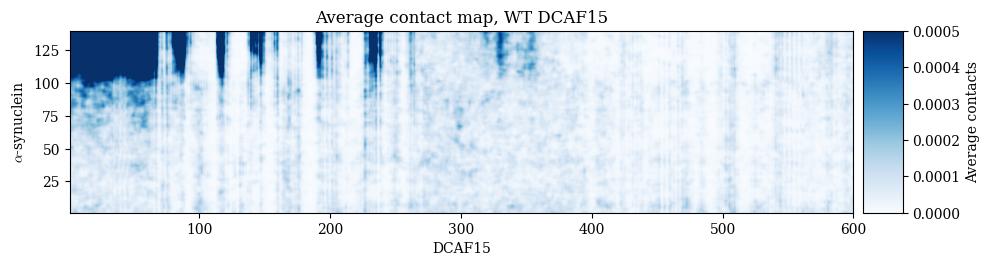

In [14]:
average_cmap = load_average_cmap(VARIANTS_DIR / 'base')

plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(10, 5))
plotMap(fig, ax, average_cmap, 'Average contacts',
        vmin=0, vmax=0.0005, cmap=plt.cm.Blues,
        xlabel='DCAF15', ylabel=r'$\alpha$-synuclein')

ax.set_title('Average contact map, WT DCAF15', loc='center')
plt.tight_layout()
plt.savefig(FIG_DIR / "contactmapWT.svg", bbox_inches="tight", pad_inches=0.05)
plt.show()


#### DCAF15 4x alanine

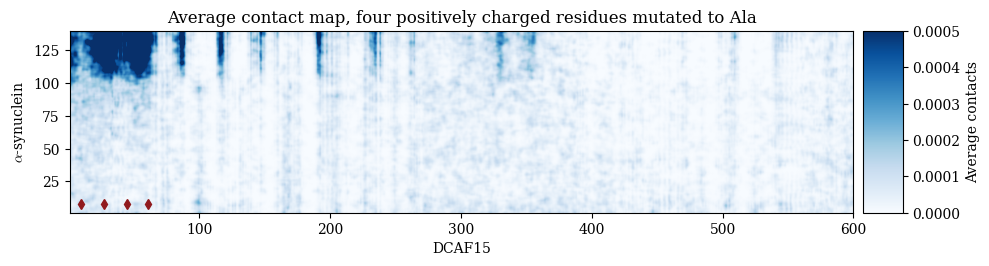

In [15]:
average_cmap = load_average_cmap(VARIANTS_DIR / 'pos4')
mutated_residues = [9, 26, 44, 60]

plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(10, 5))
plotMap(fig, ax, average_cmap, 'Average contacts',
        vmin=0, vmax=0.0005, cmap=plt.cm.Blues,
        xlabel='DCAF15', ylabel=r'$\alpha$-synuclein')

for x in mutated_residues:
    ax.plot(x + 1, 8, marker='d', color=KUred, markersize=5, clip_on=False)

ax.set_title('Average contact map, four positively charged residues mutated to Ala', loc='center')
plt.tight_layout()
plt.savefig(FIG_DIR / "pos4_cmap.svg", bbox_inches="tight", pad_inches=0.05)
plt.show()


#### DCAF15 8x alanine

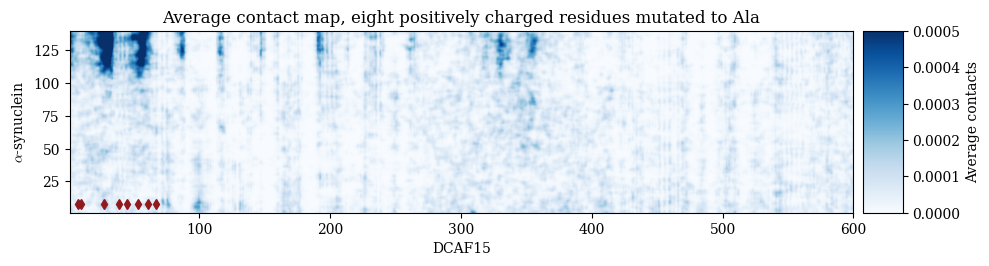

In [16]:
average_cmap = load_average_cmap(VARIANTS_DIR / 'pos8')
mutated_residues = [6, 9, 26, 38, 44, 52, 60, 66]

plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(10, 5))
plotMap(fig, ax, average_cmap, 'Average contacts',
        vmin=0, vmax=0.0005, cmap=plt.cm.Blues,
        xlabel='DCAF15', ylabel=r'$\alpha$-synuclein')

for x in mutated_residues:
    ax.plot(x + 1, 8, marker='d', color=KUred, markersize=5, clip_on=False)

ax.set_title('Average contact map, eight positively charged residues mutated to Ala', loc='center')
plt.tight_layout()
plt.savefig(FIG_DIR / "pos8_cmap.svg", bbox_inches="tight", pad_inches=0.05)
plt.show()


#### DCAF15 12x alanine

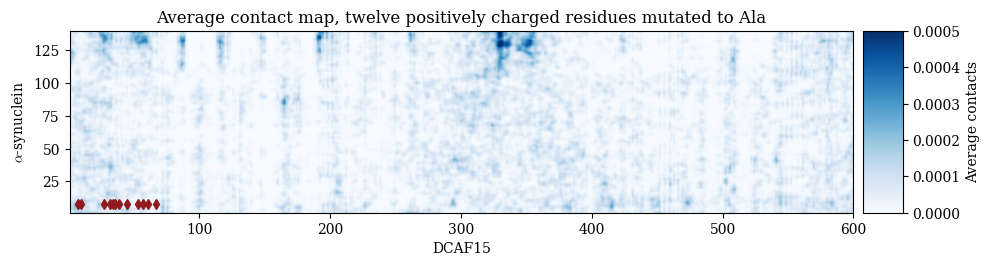

In [17]:
average_cmap = load_average_cmap(VARIANTS_DIR / 'pos12')
mutated_residues = [6, 9, 26, 31, 33, 35, 38, 44, 52, 56, 60, 66]

plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(10, 5))
plotMap(fig, ax, average_cmap, 'Average contacts',
        vmin=0, vmax=0.0005, cmap=plt.cm.Blues,
        xlabel='DCAF15', ylabel=r'$\alpha$-synuclein')

for x in mutated_residues:
    ax.plot(x + 1, 8, marker='d', color=KUred, markersize=5, clip_on=False)

ax.set_title('Average contact map, twelve positively charged residues mutated to Ala', loc='center')
plt.tight_layout()
plt.savefig(FIG_DIR / "pos12_cmap.svg", bbox_inches="tight", pad_inches=0.05)
plt.show()
